In [325]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import scipy.signal as signal
import numpy as np
from sklearn.cluster import KMeans
import librosa
import librosa.display
import matplotlib.pyplot as plt


# Solver est une classe qui permet d'obtenir les n spectogrammes des sources à partir des m spectogrammes des enregitrement ou m << n : 
Cette classe peut implementer: 
- Les librairies d'optization convexe
- Méthode IRLS 
- Méthode du gradient ( greedy )



In [326]:
import cvxpy as cp
import numpy as np

class Solvers:
    def __init__(self, Attentuation, delays, mixtures_stft, method_name, w_0=1, **args):
        """
        Initialize the solver with attenuation, delays, mixtures, and additional hyperparameters.
        
        Args:
        - Attentuation: Attenuation matrix (m x n).
        - delays: Delay matrix (m x n).
        - mixtures_stft: Short-time Fourier transform of mixtures.
        - method_name: Name of the method to use for optimization ('gard proximal', 'IRLS', or 'CVXPY').
        - w_0: A parameter for the frequency-related computation (default 1).
        - **args: Additional hyperparameters to be passed to the method.
        """
        self.Attentuation = Attentuation
        self.delays = delays
        self.mixtures_stft = mixtures_stft
        self.n_mix = Attentuation.shape[0]
        self.n_sources = Attentuation.shape[1]
        self.w_0 = w_0
        self.method_name = method_name
        self.args = args  # Store additional hyperparameters as a dictionary
        
    def get_method(self): 
        
        """
        Select the optimization method based on the provided method name.
        """
        if self.method_name == 'proximal': 
            return self.solve_pq_optimization_proximal
        elif self.method_name == 'IRLS': 
            return self.IRLS
        elif self.method_name == 'CVXPY':
            return self.solve_pq_optimization
        else:
            raise ValueError(f"Unknown method: {self.method_name}")
    
    def IRLS(self, A, b, **kwargs):
        """
        IRLS optimization function.
        
        Args:
        - A: Mixing matrix.
        - b: Mixture vector.
        - **kwargs: Additional hyperparameters for IRLS.
        
        Returns:
        - Estimated sources vector.
        """
        K = kwargs.get('K', 3)
        q = kwargs.get('q', 0.5)
        
        W = np.identity(A.shape[1])
        x_estim = np.ones(A.shape[1])
        
        for i in range(K):
            x_estim = W @ W @ A.T @ np.linalg.inv(A @ W @ W @ A.T) @ b
            z = np.abs(x_estim) ** (1 - q / 2)
            W = np.diag(z)
            
        return x_estim
    
    def A_l(self, l):
        """
        Compute the matrix A for a given time-frequency point [k, l].
        
        Args:
        - l: The time-frequency point index.
        
        Returns:
        - A_l: The computed mixing matrix at time-frequency point l.
        """
        A_l = np.zeros((self.n_mix, self.n_sources), dtype=complex)
        for i in range(self.n_mix):
            for j in range(self.n_sources):
                A_l[i, j] = self.Attentuation[i, j] * np.exp(-1j * 2 * np.pi * l * self.delays[i, j] * self.w_0)
        return A_l

    def __proximal_operator(self, x, **kwargs):
        """
        Proximal operator for the q-norm (non-convex for q < 1).
        
        Args:
        - x: The input vector (complex-valued).
        - **kwargs: Additional parameters like `q` and `lambda_param`.
        
        Returns:
        - The result of applying the proximal operator.
        """
        q = kwargs.get('q', 0.5)
        lambda_param = kwargs.get('lambda_param', 0.1)
        
        magnitude = np.abs(x)
        return np.sign(x) * np.maximum(magnitude - lambda_param, 0) ** q

    def __gradient_step(self, A, x, s_e, **kwargs):
        """
        Perform one step of the gradient descent.
        
        Args:
        - A: Mixing matrix.
        - x: Mixture vector.
        - s_e: Current source estimate.
        - **kwargs: Additional hyperparameters like learning_rate.
        
        Returns:
        - Updated s_e after the gradient descent step.
        """
        learning_rate = kwargs.get('learning_rate', 0.01)
        grad = A.T @ (A @ s_e - x)  # Compute the gradient of the loss
        return s_e - learning_rate * grad

    def solve_pq_optimization_proximal(self, A, x, **kwargs):
        """
        Solve the Pq optimization problem for a given time-frequency point using Proximal Gradient Descent.
        
        Args:
        - A: Mixing matrix at time-frequency point [k, l].
        - x: Mixture vector at time-frequency point [k, l].
        - **kwargs: Additional hyperparameters like `q`, `lambda_param`, `max_iter`, `learning_rate`.
        
        Returns:
        - s_e: Sparse source estimate at time-frequency point [k, l].
        """
        max_iter = kwargs.get('max_iter', 100)
        q = kwargs.get('q', 0.5)
        lambda_param = kwargs.get('lambda_param', 0.1)
        learning_rate = kwargs.get('learning_rate', 0.01)
        
        _, n = A.shape
        s_e = np.zeros(n, dtype=complex)
        
        for _ in range(max_iter):
            s_e = self.__gradient_step(A, x, s_e, learning_rate=learning_rate)
            s_e = self.__proximal_operator(s_e, q=q, lambda_param=lambda_param)
        
        return s_e

    def solve_pq_optimization(self, A, x, **kwargs):
        """
        Solve the Pq optimization problem for a given time-frequency point using CVXPY.
        
        Args:
        - A: Estimated mixing matrix at time-frequency point [k, l] (m x n).
        - x: Mixture vector at time-frequency point [k, l] (m x 1).
        - **kwargs: Hyperparameters for CVXPY optimization, like `q`, `epsilon`.
        
        Returns:
        - s_e: Sparse source estimate at time-frequency point [k, l].
        """
        q = kwargs.get('q', 0.5)
        epsilon = kwargs.get('epsilon', 1e-8)
        
        m, n = A.shape
        s_e = cp.Variable(n, complex=True)
        
        # Objective: Minimize the q-norm of s_e (sparsity measure)
        objective = cp.Minimize(cp.norm(cp.abs(s_e), q) + epsilon * cp.norm(s_e))
        
        # Constraint: A * s_e = x
        constraint = [A @ s_e == x]
        
        problem = cp.Problem(objective, constraint)
        problem.solve()
        
        return s_e.value

    def solve(self, **kwargs):
        """
        Apply the selected optimization method to all time-frequency points in the mixtures.
        
        Args:
        - **kwargs: Hyperparameters for the chosen method (q, lambda_param, max_iter, etc.)
        
        Returns:
        - estimated_sources: The estimated sources in the time-frequency domain.
        """
        estimated_sources = np.zeros((self.n_sources, self.mixtures_stft.shape[1], self.mixtures_stft.shape[2]), dtype=complex)
        
        for k in range(self.mixtures_stft.shape[2]):
            A_l = self.A_l(k)
            for l in range(self.mixtures_stft.shape[1]):
                x = np.array([self.mixtures_stft[i][l, k] for i in range(self.n_mix)])
                
                # Get the selected method and call it with the dynamic arguments
                method = self.get_method()
                s_e = method(A_l, x, **kwargs)
                
                estimated_sources[:, l, k] = s_e
        
        return estimated_sources
 

# Cette classe "system" applique les méthodes suivantes : 
- Calcule et plot les spectogrammes 
- Calcule et classifie les feature vectors ( Kmeans)
- Calcul la matrice de transition 
- Calcul le spectogramme des sources ( classe solver )


In [327]:
class System:
    # Constructor (__init__) to initialize attributes
    def __init__(self,  mixtures, n_sources,window_size=1024,hop_length=512,sr=16000,window_type='gaussian'):
        self.n_sources=n_sources
        self.mixtures=mixtures     # Attribute for age
        self.n_mix= len(mixtures)
        self.A=np.zeros((self.n_mix,self.n_sources))
        self.hop_length=hop_length
        self.window_size=window_size
        self.sr= sr 
        self.f_0=sr / window_size
        self.window_type=window_type
        
    def compute_gabor_transform_with_f_t(self):
        gabor_transforms = []
        for signal_data in self.mixtures:
            if self.window_type == 'gaussian':
                window = signal.windows.gaussian(self.window_size, std=self.window_size / 4)
            else:
                window = signal.windows.get_window(self.window_type, self.window_size)
            self.f, self.t, Zxx = signal.stft(signal_data, nperseg=self.window_size, noverlap=self.hop_length, window=window)
            
            gabor_transforms.append(Zxx)
        self.mixtures_st_gabor=  np.array(gabor_transforms)
    def get_stfts(self):
        return  self.mixtures_st_gabor
    def plot_mixtures_stft(self,title=""):
        for i, stft in enumerate(mixtures_stft, 1):
            plt.figure(figsize=(10, 6))
            librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft), ref=np.max), sr=self.sr, x_axis='time', y_axis='log')
            plt.colorbar(format='%+2.0f dB')
            plt.title(f"{title} {i} Spectrogram (Gabor Transform)" if title!="" else "Spectrogram")
            plt.show()
    def compute_feature_vectors(self):
        n_bins, n_frames = self.mixtures_st_gabor[0].shape  # Frequency bins and time frames
        # Initialize an array to hold the feature vectors
        self.feature_vectors = []
        for k in range(n_frames):
            for l in range(1,n_bins):
                # Compute the norm of the mixture coefficients at [k, l]
                norm = np.linalg.norm([self.mixtures_st_gabor[i][l, k] for i in range(self.n_mix)])
                if norm ==0 : 
                    norm=1
                # Normalize each STFT coefficient
                feature_vector = [np.abs(self.mixtures_st_gabor[i][l, k]) / norm for i in range(self.n_mix)]
            # Compute the phase difference (delays) between the mixtures
                phase_diffs = []
                for i in range(1, self.n_mix):
                    # Compute phase difference for each mixture pair
                    if  self.mixtures_st_gabor[0][l, k]==0:
                        div= 1e-7
                        phase_diffs.append(0)  
                    else : 
                        phase_diffs.append(0) 
                        
                        #div=self.mixtures_st_gabor[0][l, k] 
                        #phase_diff = -np.angle(self.mixtures_st_gabor[i][l, k] / div)/ ( l*2*np.pi*self.sr/self.window_size)
############################################################################################################################################
#the w_0= ? , comment on définie la fréquence fondamentale !! cett valeurs affecte les phase_diff donc les features vectors en clustering. Ainsi , les clusters centers vont êtres affectés
#  Ainsi la matrice de reconstruction sera déphasée 
############################################################################################################################################
                        # Append the phase difference to the list
                        #phase_diffs.append(phase_diff)  
                if  np.any(np.isnan(phase_diffs)):
                    print( 'oh no the problem is from the source',k,l)
                # Combine the normalized features and phase differences into one feature vector
                feature_vector.extend(phase_diffs)
                self.feature_vectors .append(feature_vector)
        self.feature_vectors = np.array(self.feature_vectors )
        
    def compute_k_means(self): 
        self.k_means= KMeans(n_clusters=self.n_sources)# Perform k-means clustering on the feature vectors

        self.k_means.fit(self.feature_vectors)  # 'feature_vectors' are your time-frequency features

        # Get the cluster labels for each time-frequency point
        self.labels = self.k_means.labels_
        self.cluster_centers_=self.k_means.cluster_centers_
    def get_cluster_centers_(self):
        return self.cluster_centers_
    def plot_clusters(self,indx1=0, indx2=1):
        # Visualize the clustering (optional, for 2D representation)
        plt.figure(figsize=(8, 6))
        plt.scatter(self.feature_vectors[:, indx1], self.feature_vectors[:, indx2], c=self.labels, cmap='viridis')
        plt.title("Feature Vector Clustering (k-means)")
        plt.xlabel("Feature 1 (normalized STFT coefficient)")
        plt.ylabel("Feature 2 (phase difference)")
        plt.colorbar(label='Cluster')
        plt.show()

    def estimate_aij_and_deltaij(self ):
        # Initialize arrays to store the results
        self.attenuations_est = np.zeros((self.n_mix, self.n_sources))  # Estimated attenuations (aij) for each source and mixture
        self.delays_est = np.zeros((self.n_mix, self.n_sources ))    # Estimated delays (deltaij) for each source and mixtures

        for cluster_idx in range(self.n_sources):
            # Extract the cluster center for the current cluster
            self.cluster_center_ = self.cluster_centers_[cluster_idx]            
            # The first m elements correspond to the normalized STFT coefficients (attenuations)
            self.attenuations_est[:self.n_mix,cluster_idx]= self.cluster_center_[:self.n_mix]
            # The remaining m-1 elements correspond to the phase differences (delays)
            self.delays_est[1:self.n_mix,cluster_idx]= self.cluster_center_[self.n_mix:]
    def get_attentuations_and_delats(self):
        return self.attenuations_est, self.delays_est
    def Mean_S_E_without_print(self, Matrix_atten=None, Matrix_delays=None ):
        try:
            assert self.delays_est.shape == Matrix_delays.shape,"Matrices X and Y must have the same shape"
            self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
            
        except: 
            pass
        try:
                    assert self.attenuations_est.shape == Matrix_atten.shape,"Matrices X and Y must have the same shape"
                    self.mse = np.mean((self.attenuations_est - Matrix_atten)**2) /  np.mean( Matrix_atten**2)
                    
        except:
             pass 
        

    def Mean_S_E(self, Matrix_atten=None, Matrix_delays=None ):
        try:
            assert self.delays_est.shape == Matrix_delays.shape,"Matrices X and Y must have the same shape"
            self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
            print( "The mean suqare error of delays is ", self.mse)
            print("The True matrix is \n", Matrix_delays.T)
            print("The estiamted matrix is \n", self.delays_est.T)
        except: 
            pass
        try:
                    assert self.attenuations_est.shape == Matrix_atten.shape,"Matrices X and Y must have the same shape"
                    self.mse = np.mean((self.attenuations_est - Matrix_atten)**2) /  np.mean( Matrix_atten**2)
                    print( "The mean suqare error of attenutaion is ", self.mse)
                    print("The True matrix is \n", Matrix_atten.T)
                    print("The estiamted matrix is \n", self.attenuations_est.T)
        except:
             pass

    
    def ecarser_attentuation_delays( self, A=None,D=None): 
        if A != None: 
            self.attenuations_est= A 
        if D != None:
            self.delays_est= D
    
    def simulate_sources_stft(self,method_name='IRLS',method_params={}):
        if method_name == 'IRLS':
            solver_irls = Solvers(self.attenuations_est,self.delays_est, self.mixtures_st_gabor, method_name, w_0=2 * np.pi * self.f_0, **method_params)
            self.stft_sources = solver_irls.solve(**method_params)
        elif method_name == 'proximal':
            solver_proximal = Solvers(self.attenuations_est,self.delays_est,self.mixtures_st_gabor, method_name, w_0=2 * np.pi * self.f_0, **method_params)
            self.stft_sources = solver_proximal.solve(**method_params)
        elif method_name == 'CVXPY':
            solver_cvxpy = Solvers(self.attenuations_est,self.delays_est, self.mixtures_st_gabor, method_name='CVXPY', w_0=1, **method_params)
            self.stft_sources = solver_cvxpy.solve(**method_params)
        return self.stft_sources
    def get_sources_stft(self):
        return self.stft_sources

# Générer des sources 

The 0-th frequency is 73 Hz
The 1-th frequency is 15 Hz
The 2-th frequency is 45 Hz


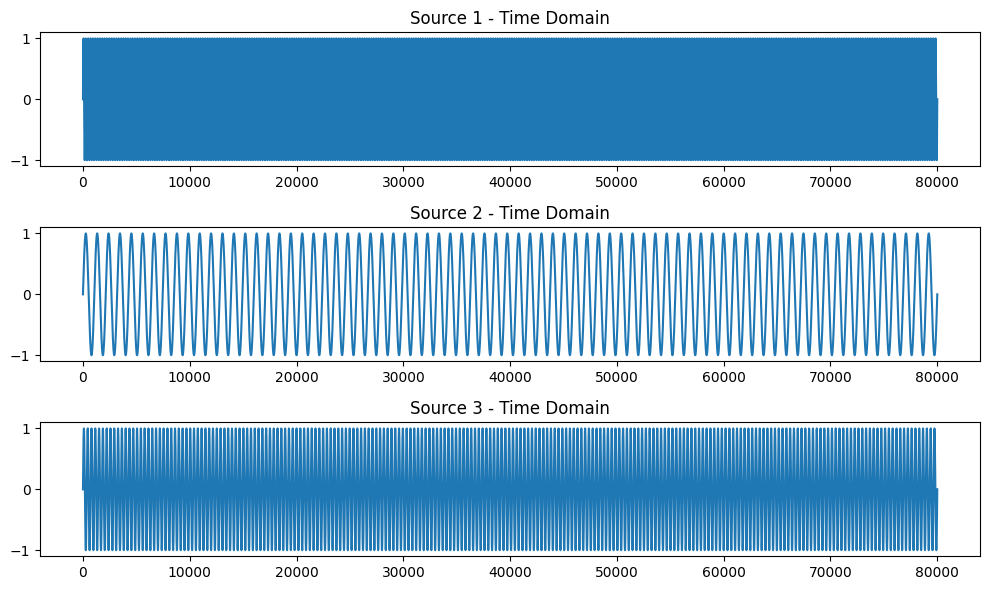

In [328]:


# Parameters
n_sources = 3 # Number of sources (speech signals)
n_mixtures = 2  # Number of mixtures
duration = 5  # Duration of the signals in seconds
sr = 16000 #16000  # Sample rate

# Function to generate synthetic sources with sufficiently spaced frequencies
def generate_sources(n, duration, sr=16000, f_min=10, f_max=500, min_spacing=50):
    t = np.linspace(0, duration, int(duration * sr))
    sources = []
    frequencies = []  # To store the generated frequencies
    
    for i in range(n):
        while True:
            # Generate a random frequency for each source
            frequency = np.random.randint(f_min, f_max)
            
            # Check if the frequency is sufficiently spaced from the existing ones
            if all(abs(frequency - f) >= min_spacing for f in frequencies):
                frequencies.append(frequency)
                break  # If valid, add it and break out of the loop
        
        # Generate the sine wave for the source
        source = np.sin(2 * np.pi * frequency * t)  # Sine wave with the generated frequency
        print(f'The {i}-th frequency is {frequency} Hz')  # Print the frequency for each source
        sources.append(source)
    
    return np.array(sources)

# Function to plot the time-domain signals
def plot_time_domain_signals(sources, sr=sr, sr_or_mix= 'Source'):
    plt.figure(figsize=(10, 6))
    for i, source in enumerate(sources):
        plt.subplot(len(sources), 1, i + 1)
        plt.plot(source)
        plt.title(f"{sr_or_mix} {i + 1} - Time Domain")
    plt.tight_layout()
    plt.show()




f_min = 10
f_max = 100
min_spacing = (f_max-f_min)//(n_sources*2) # Minimum spacing between frequencies


# Generate synthetic sources with sufficient frequency spacing
sources = generate_sources(n_sources, duration, sr, f_min=f_min, f_max=f_max, min_spacing=min_spacing)

# Plot the time-domain signals
plot_time_domain_signals(sources, sr, 'Source')


# Génerer les enregistrement 

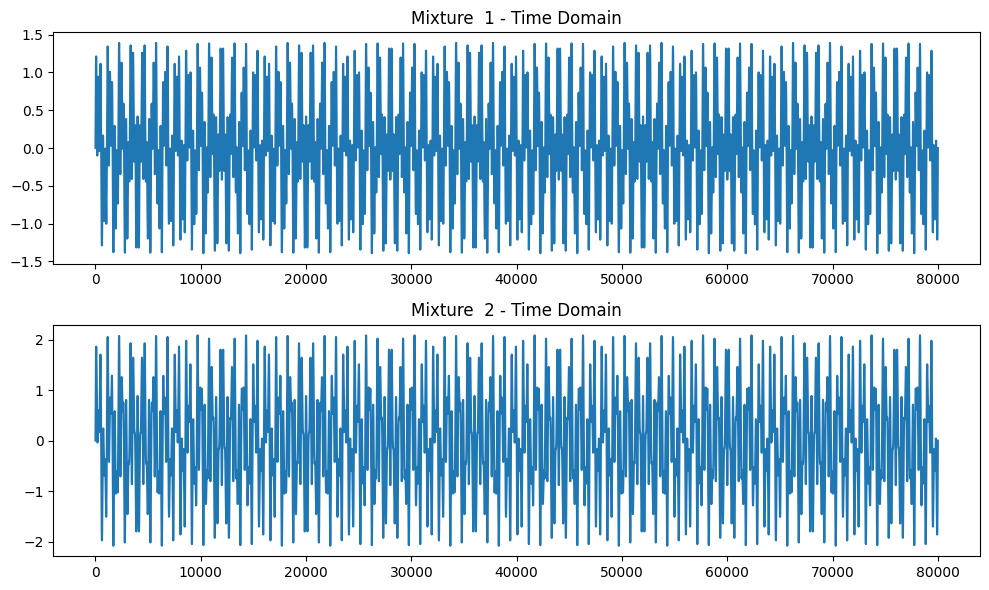

In [329]:
def delay_source(source, rank ):
    delayed= np.roll(source, rank)
    delayed[0:rank]=np.zeros(rank)
    return delayed
# Function to simulate the mixing model

# Function to simulate the mixing model
def simulate_mixing(sources, mixing_matrix, delays, sr=16000):
    m, n = mixing_matrix.shape
    mixtures = np.zeros((m, len(sources[0])))  # Initialize mixtures matrix
    
    for i in range(m):
        for j in range(n):
            # Apply delays and attenuations
            delayed_source =  delay_source(sources[j],  int(delays[i, j] * sr)) 
            mixtures[i] += mixing_matrix[i, j] * delayed_source
    
    return mixtures


# Define a mixing matrix A (n_mixtures x n_sources)
mixing_matrix = np.random.rand(n_mixtures, n_sources)  # Random mixing matrix
mixing_matrix = mixing_matrix / np.linalg.norm(mixing_matrix, axis=0)  # Normalize columns


# Define delays between sources (in seconds)
delays = np.random.rand(n_mixtures, n_sources) *0 # Random delays between sources
delays[0,:]= np.zeros(n_sources)

# Simulate the mixing process
mixtures = simulate_mixing(sources, mixing_matrix, delays, sr)

plot_time_domain_signals(mixtures, sr_or_mix="Mixture ")

# Compute STFT ( gaussian)

In [330]:
n_fft_0= 1024 
hop_length_0=512
# Function to compute the Gabor transform of signals
def compute_gabor_transform_with_f_t(signals, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian'):
    gabor_transforms = []
    for signal_data in signals:
        if window_type == 'gaussian':
            window = signal.windows.gaussian(window_size, std=window_size / 4)
        else:
            window = signal.windows.get_window(window_type, window_size)
        f, t, Zxx = signal.stft(signal_data, nperseg=window_size, noverlap=hop_length, window=window)
        
        gabor_transforms.append(Zxx)
    return np.array(gabor_transforms),f,t
mixtures_stft,f,t = compute_gabor_transform_with_f_t(mixtures, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
sources_stft,f,t = compute_gabor_transform_with_f_t(sources, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
# Function to plot the spectrogram of a signal
def plot_spectrogram(stft_matrix, sr=sr, title="Spectrogram"):
    plt.figure(figsize=(10, 6))
    print( np.max(np.abs(stft_matrix)))
    librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft_matrix), ref=np.max), sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.show()



# toute la procédure 

In [331]:
window_size= 1024
hop_length=512



The 0-th frequency is 343 Hz
The 1-th frequency is 161 Hz
The 2-th frequency is 282 Hz
The 3-th frequency is 38 Hz


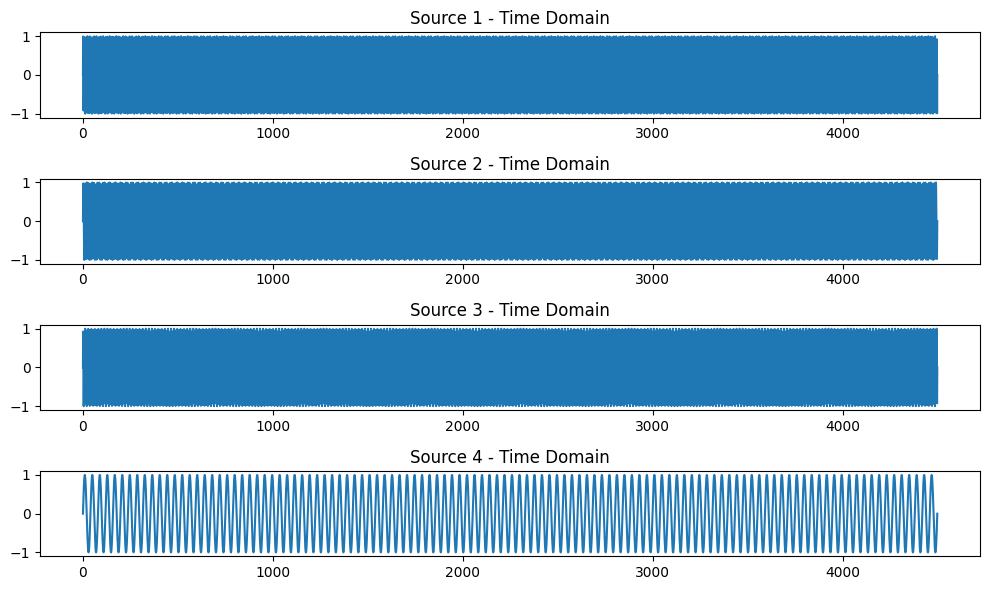

0.4541050548797206


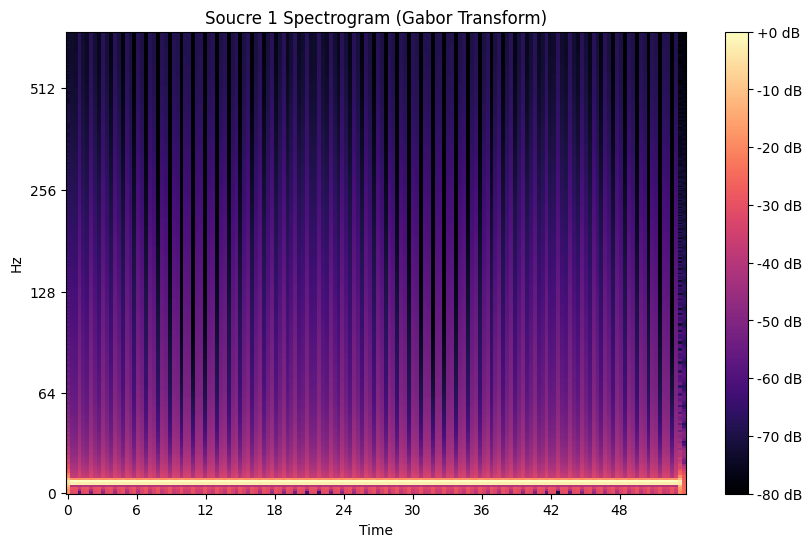

0.5056389276022971


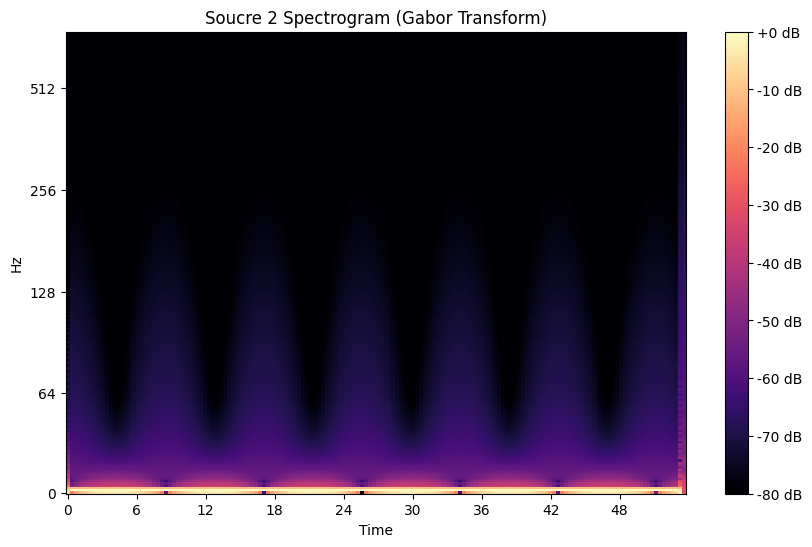

0.49655841635945114


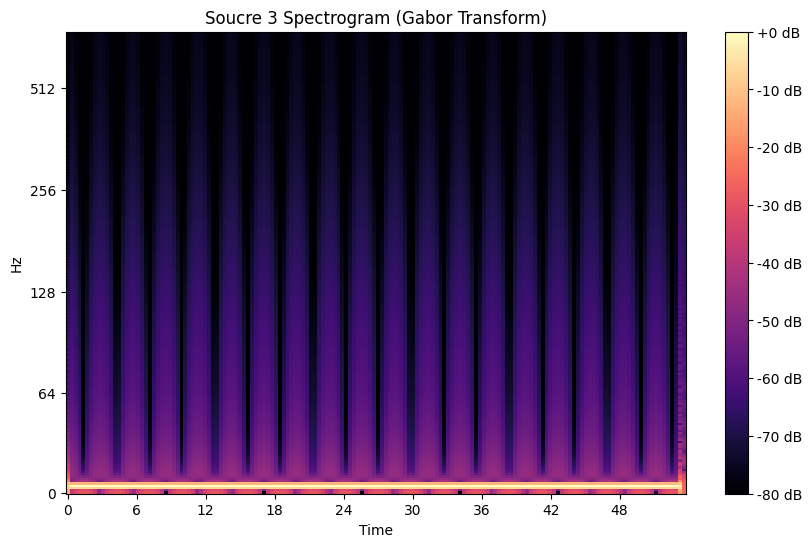

In [332]:
# Parameters
n_sources = 4 # Number of sources (speech signals)
n_mixtures = 2  # Number of mixtures
duration = 3  # Duration of the signals in seconds
sr = 1500 #16000  # Sample rate
f_min = 10
f_max = 500
min_spacing = (f_max-f_min)//(n_sources*2) # Minimum spacing between frequencies
# Generate synthetic sources with sufficient frequency spacing
sources = generate_sources(n_sources, duration, sr, f_min=f_min, f_max=f_max, min_spacing=min_spacing)
plot_time_domain_signals(sources, sr, 'Source')
# Plot the spectrogram for each mixture
for i, stft in enumerate(sources_stft, 1):
    plot_spectrogram(stft, sr=sr, title=f"Soucre {i} Spectrogram (Gabor Transform)")


0.4800865226601511


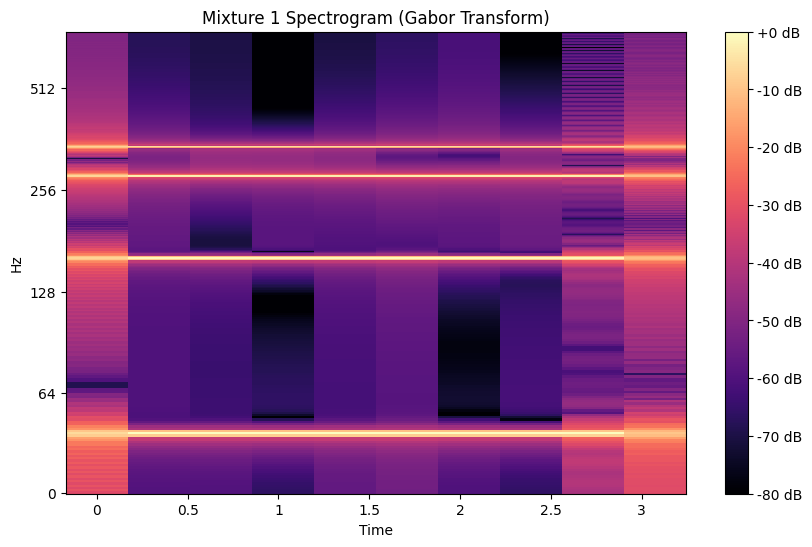

0.2756429803916811


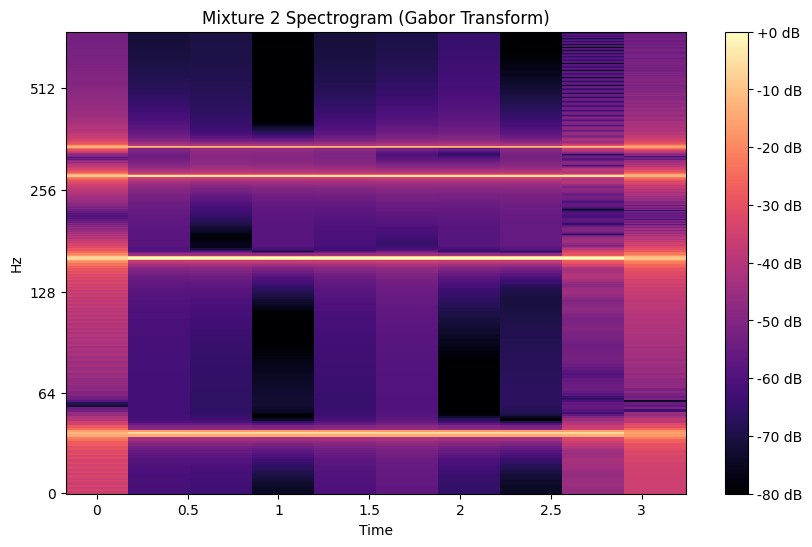

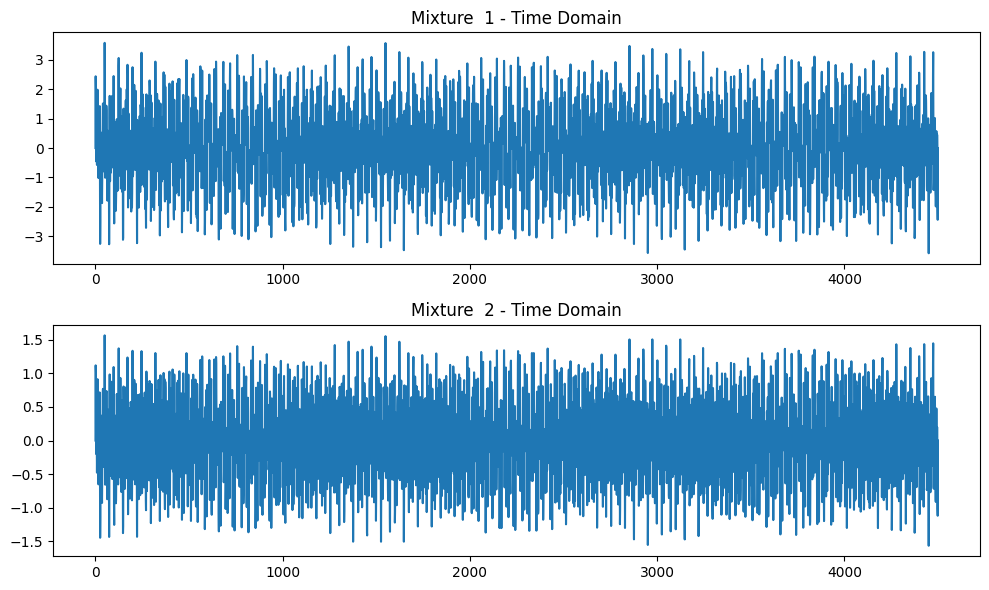

In [333]:

# Define a mixing matrix A (n_mixtures x n_sources)
mixing_matrix = np.random.rand(n_mixtures, n_sources)  # Random mixing matrix
mixing_matrix = mixing_matrix / np.linalg.norm(mixing_matrix, axis=0)  # Normalize columns
# Define delays between sources (in seconds)
delays = np.random.rand(n_mixtures, n_sources) *0 # Random delays between sources
delays[0,:]= np.zeros(n_sources)
# Simulate the mixing process
mixtures = simulate_mixing(sources, mixing_matrix, delays, sr)


mixtures_stft,f,t = compute_gabor_transform_with_f_t(mixtures, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
sources_stft,f,t = compute_gabor_transform_with_f_t(sources, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
# Plot the spectrogram for each mixture
for i, stft in enumerate(mixtures_stft, 1):
    plot_spectrogram(stft, sr=sr, title=f"Mixture {i} Spectrogram (Gabor Transform)")
plot_time_domain_signals(mixtures, sr_or_mix="Mixture ")


The 0-th frequency is 129 Hz
The 1-th frequency is 393 Hz
The 2-th frequency is 322 Hz
The 3-th frequency is 493 Hz
0.4967295032773685


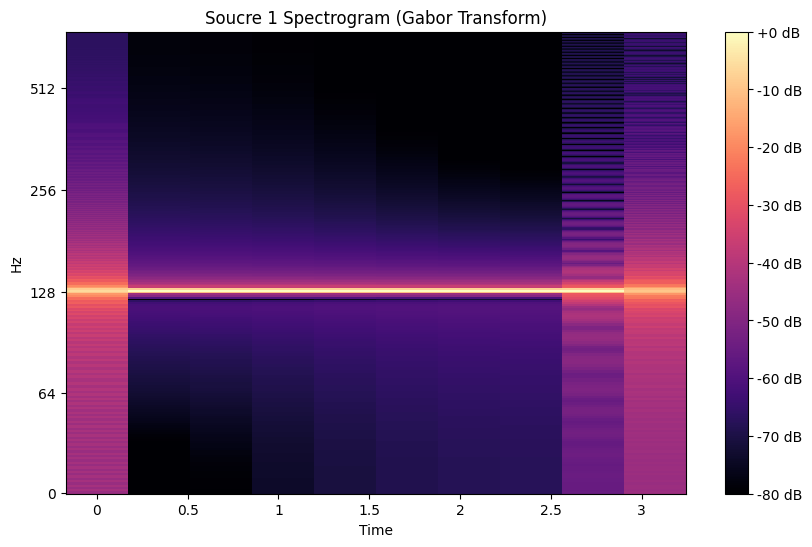

0.44497881409388906


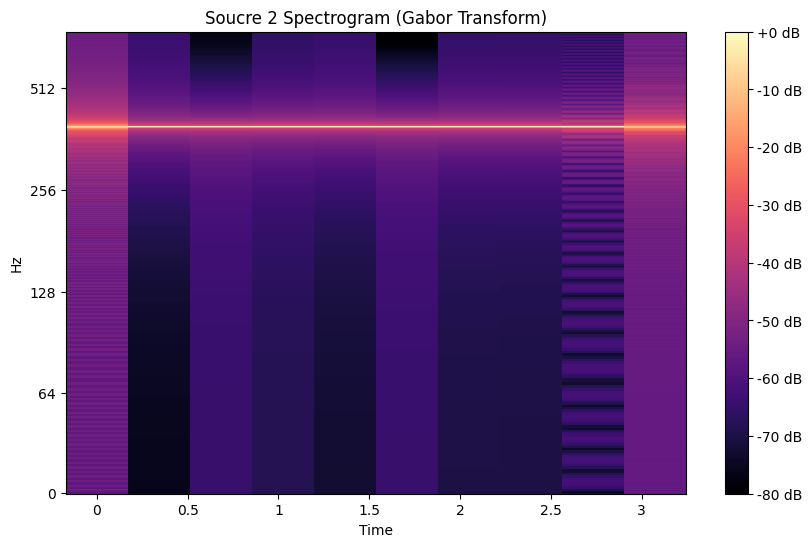

0.49172492179630833


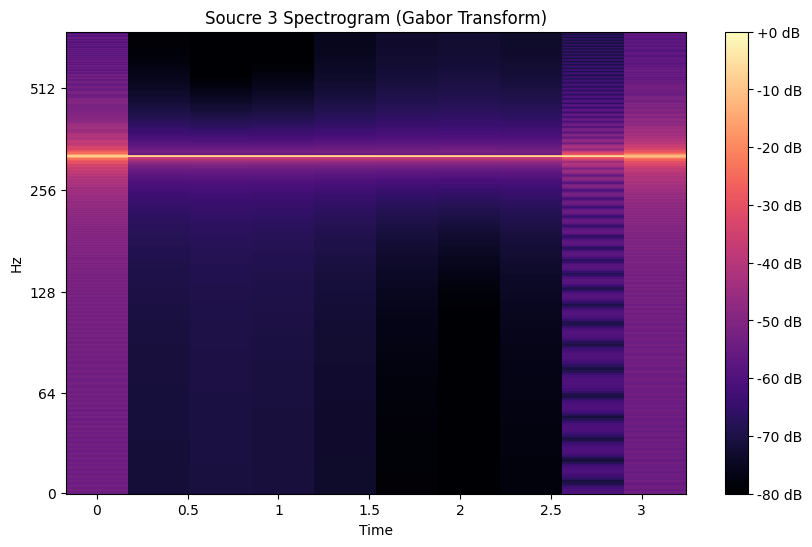

0.43787193736842867


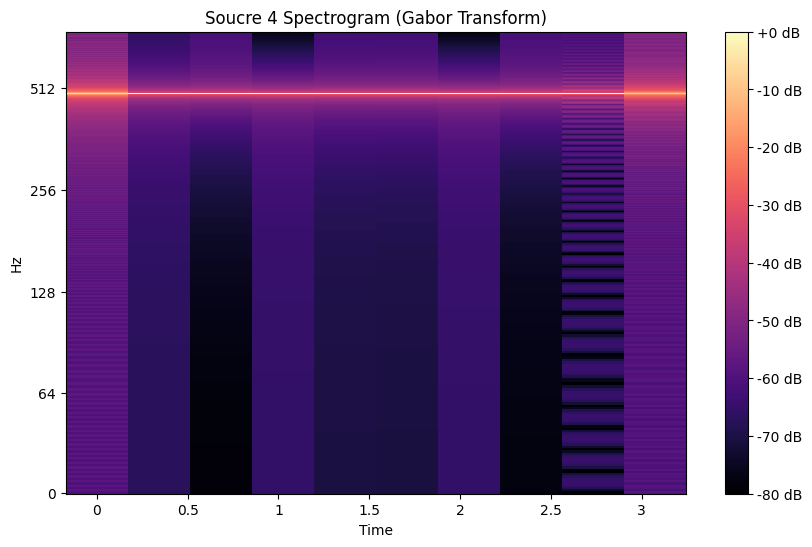

0.47835571772033336


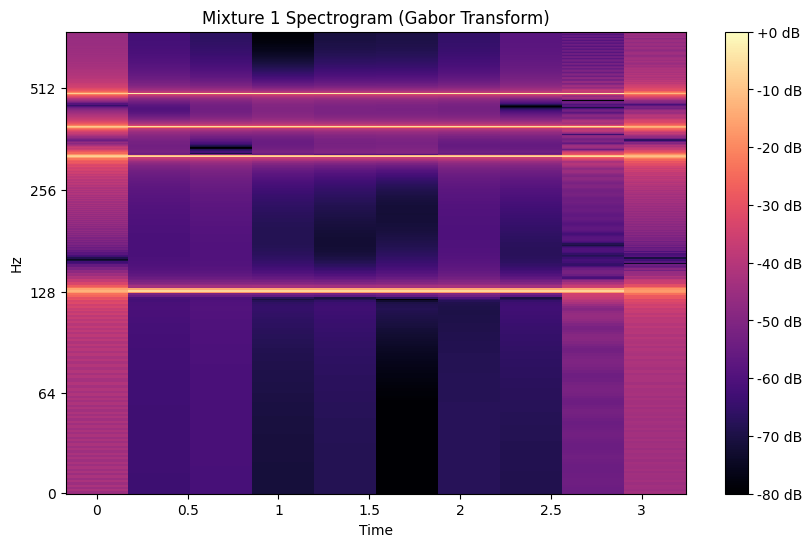

0.4485473300921373


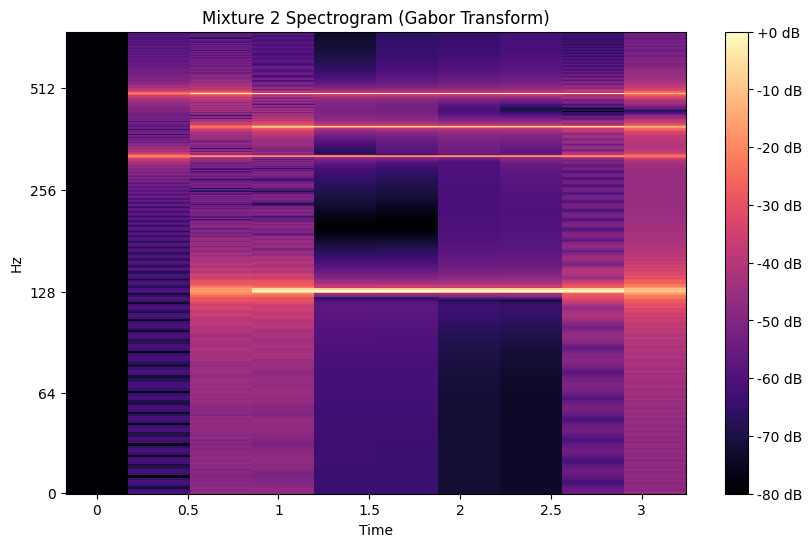

In [334]:
# Parameters
n_sources = 4 # Number of sources (speech signals)
n_mixtures = 2  # Number of mixtures
duration = 3  # Duration of the signals in seconds
sr = 1500 #16000  # Sample rate
f_min = 10
f_max = 500
min_spacing = (f_max-f_min)//(n_sources*2) # Minimum spacing between frequencies
# Generate synthetic sources with sufficient frequency spacing
sources = generate_sources(n_sources, duration, sr, f_min=f_min, f_max=f_max, min_spacing=min_spacing)
# Define a mixing matrix A (n_mixtures x n_sources)
mixing_matrix = np.random.rand(n_mixtures, n_sources)  # Random mixing matrix
mixing_matrix = mixing_matrix / np.linalg.norm(mixing_matrix, axis=0)  # Normalize columns
# Define delays between sources (in seconds)
delays = np.random.rand(n_mixtures, n_sources)  # Random delays between sources
delays[0,:]= np.zeros(n_sources)
# Simulate the mixing process
mixtures = simulate_mixing(sources, mixing_matrix, delays, sr)
mixtures_stft,f,t = compute_gabor_transform_with_f_t(mixtures, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
sources_stft,f,t = compute_gabor_transform_with_f_t(sources, window_size=n_fft_0, hop_length=hop_length_0, window_type='gaussian')
# Plot the spectrogram for each mixture
for i, stft in enumerate(sources_stft, 1):
    plot_spectrogram(stft, sr=sr, title=f"Soucre {i} Spectrogram (Gabor Transform)")
# Plot the spectrogram for each mixture
for i, stft in enumerate(mixtures_stft, 1):
    plot_spectrogram(stft, sr=sr, title=f"Mixture {i} Spectrogram (Gabor Transform)")


In [335]:
method_names=['IRLS','proximal','CVXPY']
method_parameters={}
method_parameters['proximal']= {'q': 0.1, 'lambda_param': 0.0001, 'max_iter': 150}

method_parameters['IRLS']= {'K': 10, 'q': 0.7}
method_parameters['CVXPY']={'q': 1, 'epsilon': 1e-8}

# Applique les méthodes 


###################################################The method is  IRLS #########################################################################


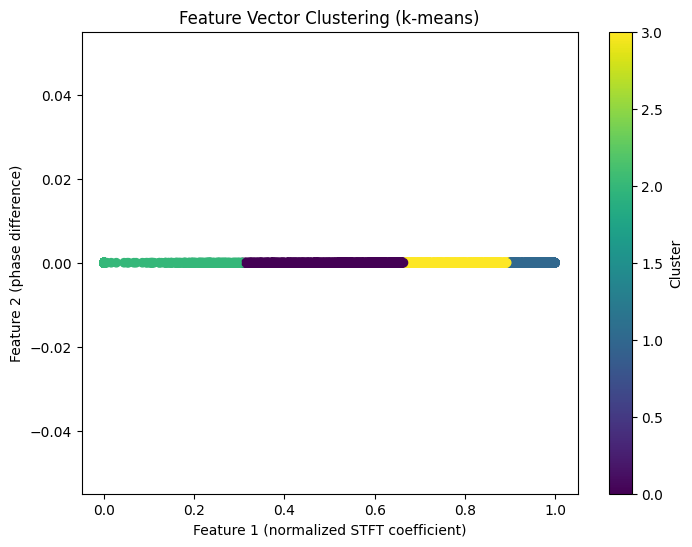

In [336]:
mn='IRLS'
print("###################################################The method is ",mn , "#########################################################################")
    #inite le systeme 
system1= System(mixtures, n_sources, window_size= window_size,hop_length=hop_length,sr= sr)
# conclure le spectogramme
system1.compute_gabor_transform_with_f_t()
# compute feature vectors 
system1.compute_feature_vectors()
# Classiciation 
system1.compute_k_means()
system1.plot_clusters(indx1=1, indx2=2)

# Question : je n'arrive pas à reconstruire les la matrice d'atténuation 
peut être ça peut être à la construction des phases ( deuxième partie de feature vectors ) ( amplitude et w_0)

The mean suqare error of delays is  1.0
The True matrix is 
 [[0.         0.84744636]
 [0.         0.89493623]
 [0.         0.38989421]
 [0.         0.53724355]]
The estiamted matrix is 
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
The mean suqare error of attenutaion is  0.18466020626123103
The True matrix is 
 [[0.43013888 0.90276273]
 [0.75670399 0.65375766]
 [0.97218364 0.23421992]
 [0.7504185  0.66096299]]
The estiamted matrix is 
 [[0.84491393 0.52309161]
 [0.23948796 0.9629066 ]
 [0.99159861 0.07006048]
 [0.61649273 0.77972942]]
0.03610041429210111


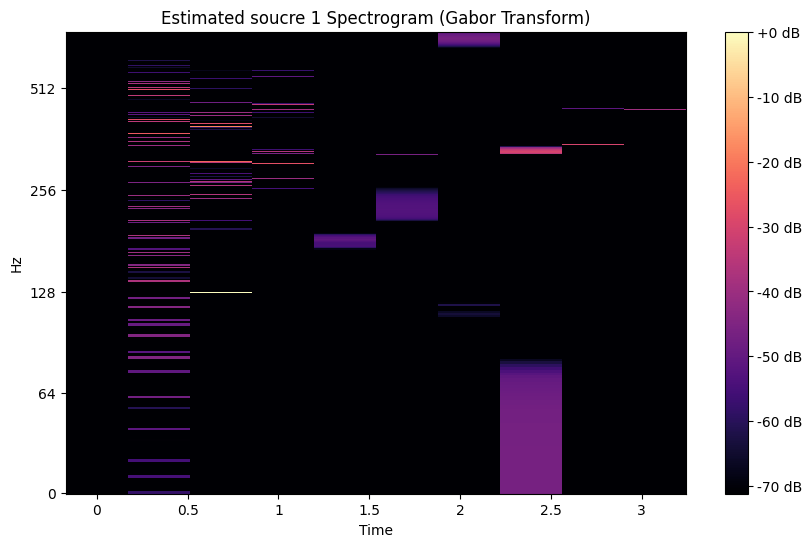

0.4820868543343629


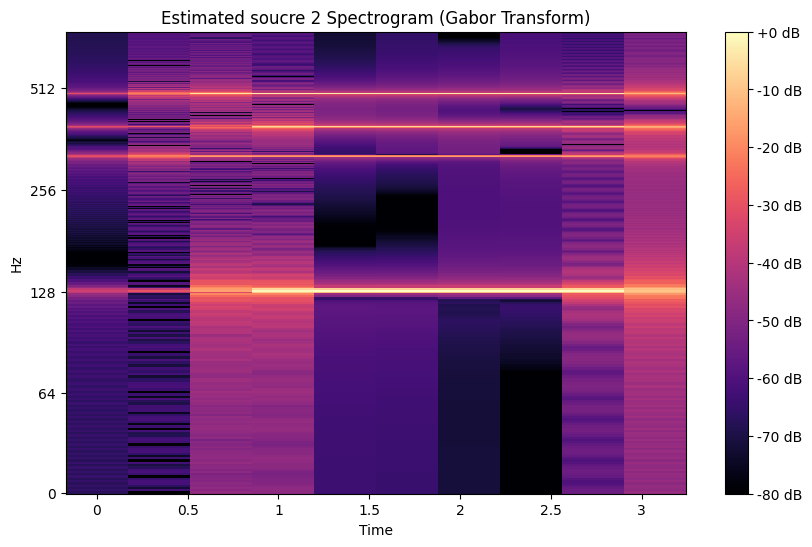

0.5144656922925669


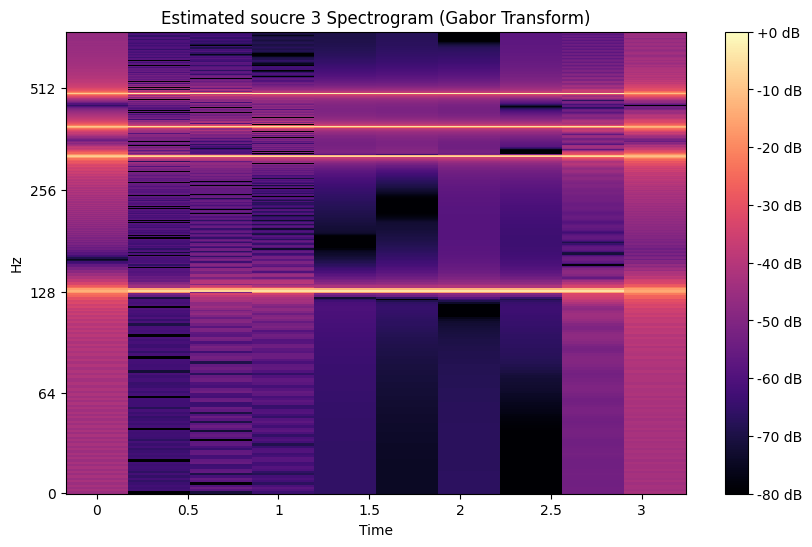

0.04735688743792353


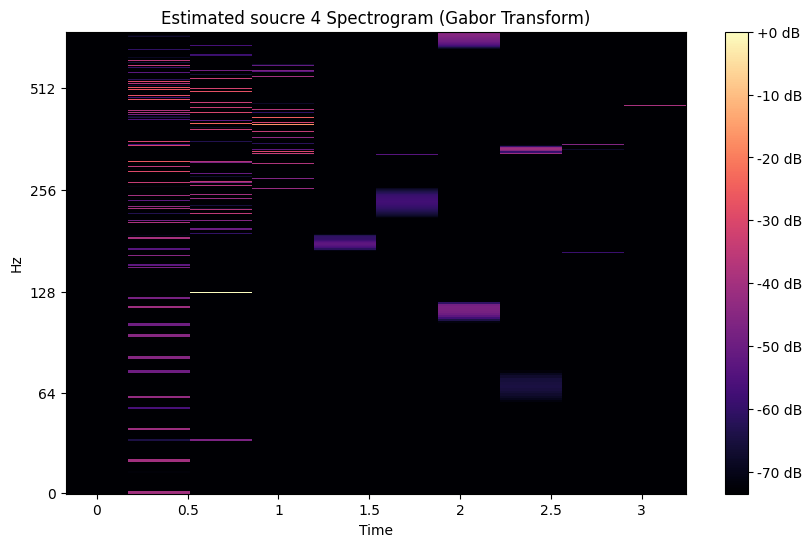

In [337]:
system1.estimate_aij_and_deltaij()
system1.Mean_S_E(mixing_matrix,delays)
system1.simulate_sources_stft(method_name=mn,method_params=method_parameters[mn] )
rt=system1.get_sources_stft()
for i, stft in enumerate(rt, 1):
        plot_spectrogram(stft, sr=sr, title=f"Estimated soucre {i} Spectrogram (Gabor Transform)")

In [338]:
method_names=['IRLS','proximal','CVXPY']
method_parameters={}
method_parameters['proximal']= {'q': 0.001, 'lambda_param': 0.001, 'max_iter': 2*150}

method_parameters['IRLS']= {'K': 10, 'q': 0.01}
method_parameters['CVXPY']={'q': 1, 'epsilon': 1e-8}

In [339]:
sr=16000
(f_max-f_min )/ 10

49.0

In [340]:
f_max=8000
min_spacing=(f_max-f_min)/20

In [341]:
n_sources= 4
n_mixtures= 2
f_min
sources = generate_sources(n_sources, duration, sr, f_min=f_min, f_max=f_max, min_spacing=min_spacing)
mixing_matrix = np.random.rand(n_mixtures, n_sources)  # Random mixing matrix
mixing_matrix = mixing_matrix / np.linalg.norm(mixing_matrix, axis=0)  # Normalize columns
delays = np.random.rand(n_mixtures, n_sources) *0 
mixtures = simulate_mixing(sources, mixing_matrix, delays, sr)

The 0-th frequency is 7321 Hz
The 1-th frequency is 1869 Hz
The 2-th frequency is 3027 Hz
The 3-th frequency is 6233 Hz


In [342]:
results={}
maxi_sources= 10
maxi_capteurs= 10
window_size= 1024
hop_length= 512
N_essays= 10
eps=0.05
for n_mixtures in range(2,maxi_capteurs): 
    for n_sources in range(n_mixtures,maxi_sources ):
        print("Test: n_mixtures =", n_mixtures, "     n_sources = " , n_sources)
        sources = generate_sources(n_sources, duration, sr, f_min=f_min, f_max=f_max, min_spacing=min_spacing)
        mixing_matrix = np.random.rand(n_mixtures, n_sources)  # Random mixing matrix
        mixing_matrix = mixing_matrix / np.linalg.norm(mixing_matrix, axis=0)  # Normalize columns
        delays = np.random.rand(n_mixtures, n_sources) *0 
        mixtures = simulate_mixing(sources, mixing_matrix, delays, sr)
        system1= System(mixtures, n_sources, window_size= window_size,hop_length=hop_length,sr= sr)
        system1.compute_gabor_transform_with_f_t()
        system1.compute_feature_vectors()
        best_mse=np.inf
        best_attentuation= None
        for _ in range(N_essays): 
            system1.compute_k_means()
            system1.estimate_aij_and_deltaij()
            system1.delays_est=system1.delays_est 
            system1.Mean_S_E_without_print(mixing_matrix,delays)
            if system1.mse < best_mse : 
                best_attentuation = system1.attenuations_est
            if system1.mse < eps : 
                break
        system1.attenuations_est= best_attentuation
        system1.Mean_S_E_without_print(mixing_matrix,delays)
        results[n_mixtures,n_sources ]= system1.mse
        print( "The mean suqare error of attenutaion is ", system1.mse)
        
        
                


Test: n_mixtures = 2      n_sources =  2
The 0-th frequency is 6100 Hz
The 1-th frequency is 6573 Hz


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide

The mean suqare error of attenutaion is  0.1409444637073885
Test: n_mixtures = 2      n_sources =  3
The 0-th frequency is 7101 Hz
The 1-th frequency is 2146 Hz
The 2-th frequency is 6547 Hz


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


The mean suqare error of attenutaion is  0.026946857256122565
Test: n_mixtures = 2      n_sources =  4
The 0-th frequency is 458 Hz
The 1-th frequency is 2280 Hz
The 2-th frequency is 3833 Hz
The 3-th frequency is 4572 Hz


...

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide

The mean suqare error of attenutaion is  0.38219922397446815
Test: n_mixtures = 9      n_sources =  9
The 0-th frequency is 7523 Hz
The 1-th frequency is 3988 Hz
The 2-th frequency is 6071 Hz
The 3-th frequency is 678 Hz
The 4-th frequency is 2740 Hz
The 5-th frequency is 2210 Hz
The 6-th frequency is 7000 Hz
The 7-th frequency is 3198 Hz
The 8-th frequency is 4554 Hz


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide

The mean suqare error of attenutaion is  0.3781731211734526


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


In [343]:
results

{(2, 2): 0.1409444637073885,
 (2, 3): 0.026946857256122565,
 (2, 4): 0.04281075700703469,
 (2, 5): 0.15752074733402352,
 (2, 6): 0.4623433077379371,
 (2, 7): 0.09108129372802577,
 (2, 8): 0.20529456914393268,
 (2, 9): 0.45375397258022243,
 (3, 3): 0.012119612595921172,
 (3, 4): 0.18973622491604655,
 (3, 5): 0.33185223766308003,
 (3, 6): 0.2662509414037,
 (3, 7): 0.18487707845311008,
 (3, 8): 0.21862886623418204,
 (3, 9): 0.20244873999007784,
 (4, 4): 0.03748047080812314,
 (4, 5): 0.3854829355690207,
 (4, 6): 0.3128867370896479,
 (4, 7): 0.51626443331502,
 (4, 8): 0.17990319648721356,
 (4, 9): 0.3475107124933239,
 (5, 5): 0.24403307068934224,
 (5, 6): 0.1805870372649687,
 (5, 7): 0.26743400421234115,
 (5, 8): 0.45233223746888856,
 (5, 9): 0.2981489809022491,
 (6, 6): 0.2456733178510391,
 (6, 7): 0.16398192067579362,
 (6, 8): 0.3214397854742292,
 (6, 9): 0.29939778258895283,
 (7, 7): 0.2401514909426609,
 (7, 8): 0.4225042251885626,
 (7, 9): 0.2875152914216063,
 (8, 8): 0.3079121909373415

In [344]:
method_names=['IRLS','proximal','CVXPY']
method_parameters={}
method_parameters['proximal']= {'q': 0.001, 'lambda_param': 0.001, 'max_iter': 2*150}

method_parameters['IRLS']= {'K': 10, 'q': 0.01}
method_parameters['CVXPY']={'q': 1, 'epsilon': 1e-8}

The 0-th frequency is 5887 Hz
The 1-th frequency is 3588 Hz
The 2-th frequency is 4147 Hz
###################################################The method is  IRLS #########################################################################


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide

The mean suqare error of attenutaion is  0.08493807211547376
0.10912665538048008


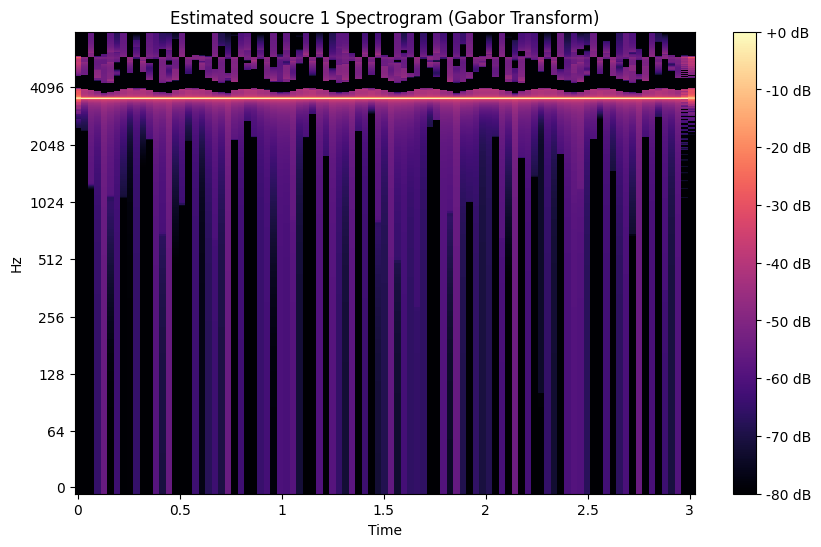

0.51432561096601


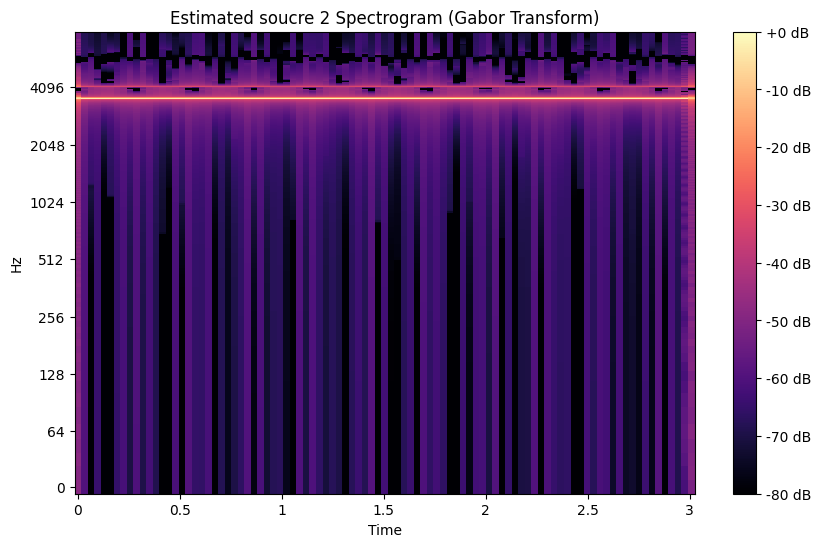

0.46500034043077765


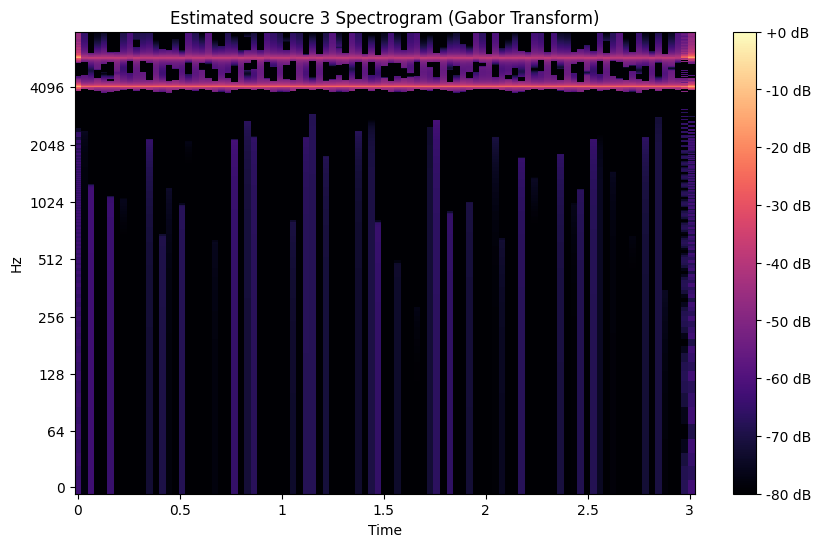

###################################################The method is  proximal #########################################################################


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide

The mean suqare error of attenutaion is  0.28361802115439366
1.0000068616149465


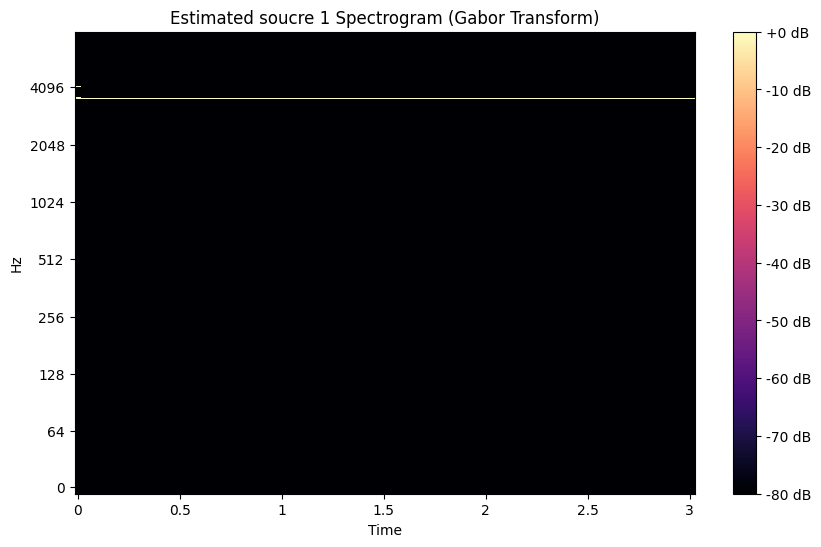

1.0000050317007825


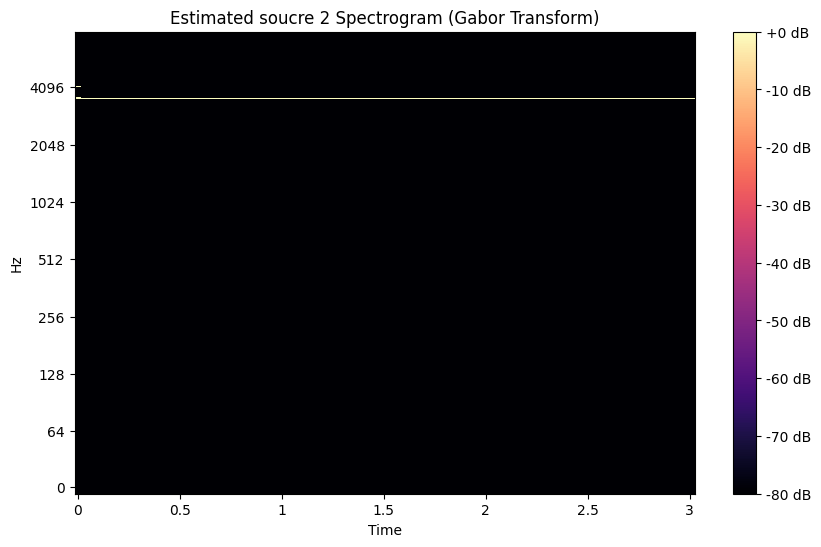

0.9999892960987686


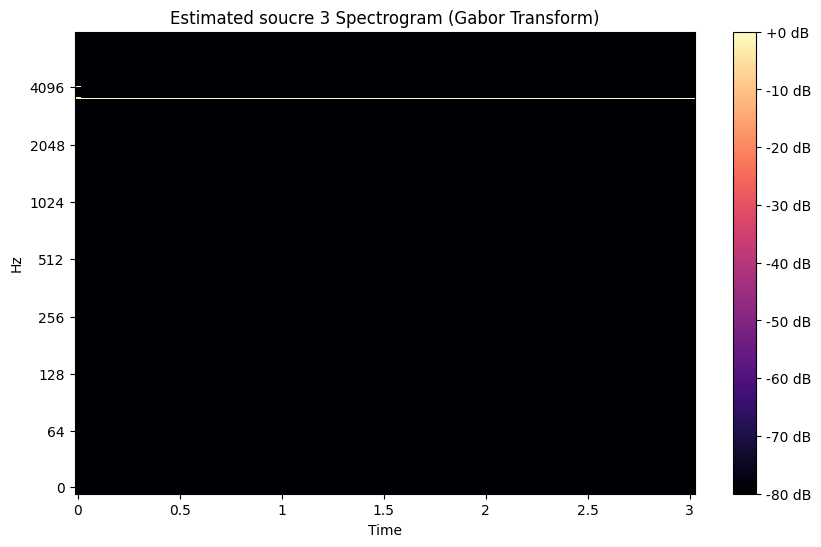

###################################################The method is  CVXPY #########################################################################


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:108: RuntimeWarning: invalid value encountered in scalar divide

The mean suqare error of attenutaion is  0.11529729311555122
0.4650001965344046


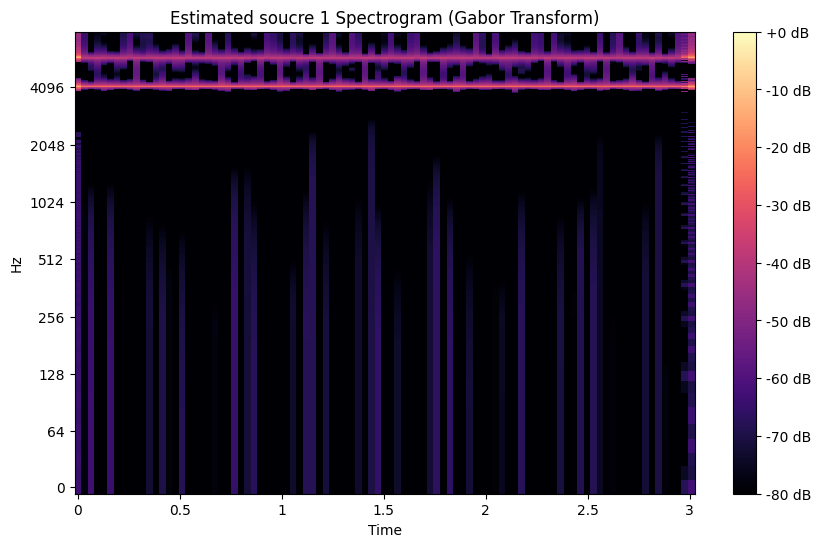

0.5143256101050672


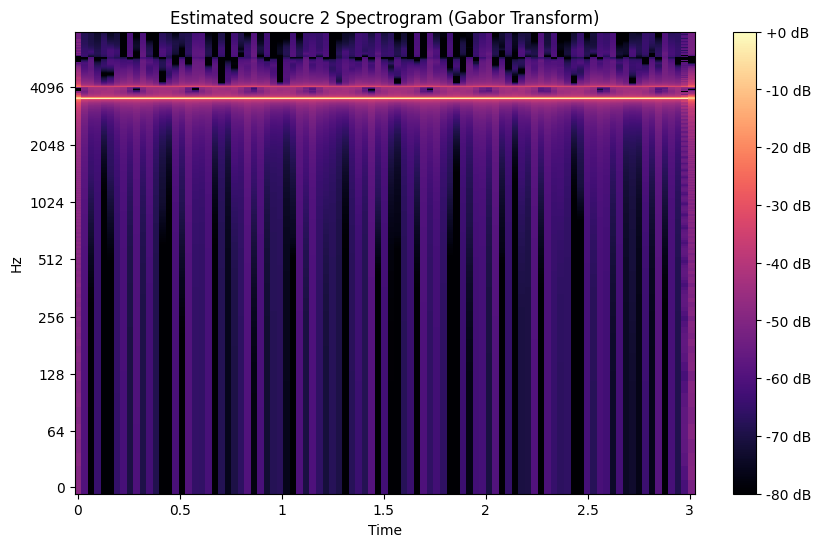

0.10912665585009264


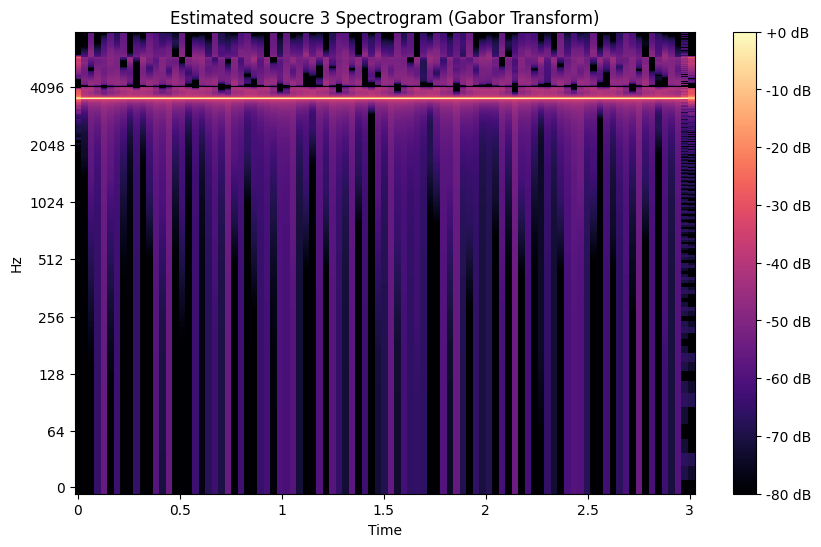

In [345]:
n_sources = 3
n_mixtures = 2 
duration = 3
sr=16000
f_max= 8000
f_min = 10 
min_spacing= (f_max- f_min)//20
results_method={}
sources = generate_sources(n_sources, duration, sr, f_min=f_min, f_max=f_max, min_spacing=min_spacing)
mixing_matrix = np.random.rand(n_mixtures, n_sources)  # Random mixing matrix
mixing_matrix = mixing_matrix / np.linalg.norm(mixing_matrix, axis=0)  # Normalize columns
delays = np.random.rand(n_mixtures, n_sources) *0 
mixtures = simulate_mixing(sources, mixing_matrix, delays, sr)
for mn in method_names: 
    print("###################################################The method is ",mn , "#########################################################################")
    system1= System(mixtures, n_sources, window_size= window_size,hop_length=hop_length,sr= sr)
    system1.compute_gabor_transform_with_f_t()
    system1.compute_feature_vectors()
    best_mse=np.inf
    best_attentuation= None
    for _ in range(N_essays): 
          system1.compute_k_means()
          system1.estimate_aij_and_deltaij()
          system1.delays_est=system1.delays_est 
          system1.Mean_S_E_without_print(mixing_matrix,delays)
          if system1.mse < best_mse : 
               best_attentuation = system1.attenuations_est
          if system1.mse < eps : 
               break
    system1.attenuations_est= best_attentuation
    system1.Mean_S_E_without_print(mixing_matrix,delays)
    results_method[mn]= system1.mse
    print( "The mean suqare error of attenutaion is ", system1.mse)
    system1.simulate_sources_stft(method_name=mn,method_params=method_parameters[mn] )
    rt=system1.get_sources_stft()
    for i, stft in enumerate(rt, 1):
        plot_spectrogram(stft, sr=sr, title=f"Estimated soucre {i} Spectrogram (Gabor Transform)")


In [346]:
results_method

{'IRLS': 0.08493807211547376,
 'proximal': 0.28361802115439366,
 'CVXPY': 0.11529729311555122}

###################################################The method is  IRLS #########################################################################


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:123: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


The mean suqare error of delays is  nan
The True matrix is 
 [[0. 0.]
 [0. 0.]
 [0. 0.]]
The estiamted matrix is 
 [[0. 0.]
 [0. 0.]
 [0. 0.]]
The mean suqare error of attenutaion is  0.11534697679093386
The True matrix is 
 [[0.89647335 0.44309765]
 [0.99984315 0.0177111 ]
 [0.93583791 0.35243072]]
The estiamted matrix is 
 [[0.89979909 0.42689041]
 [0.9800761  0.18274284]
 [0.58079003 0.79070231]]


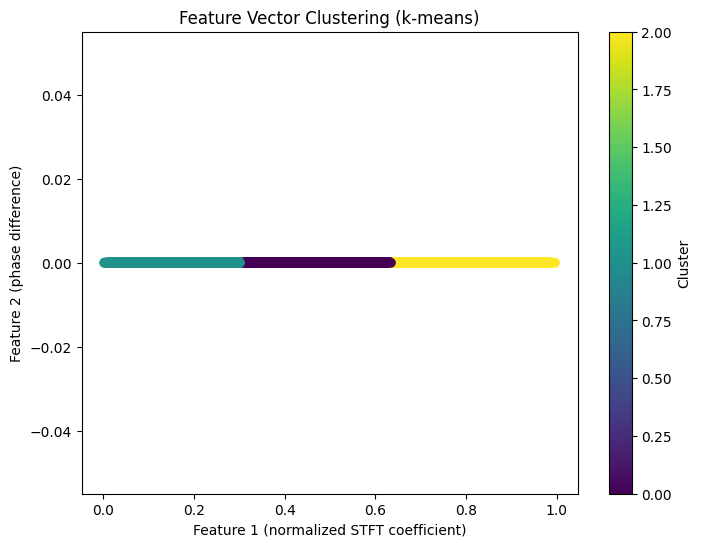

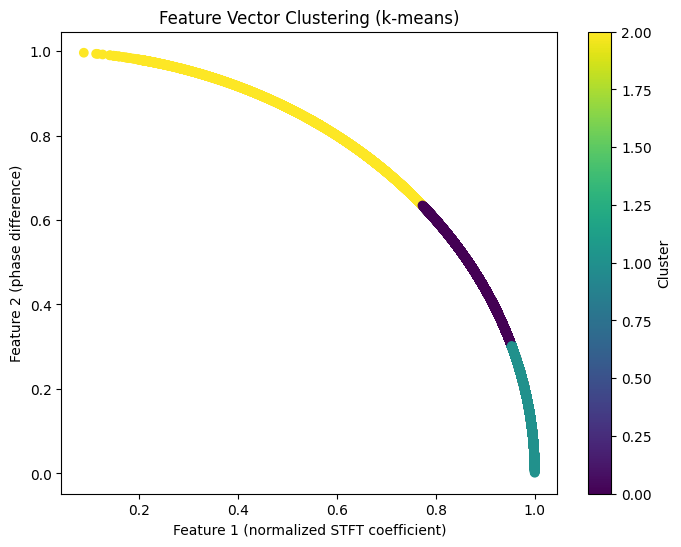

0.4650619134975303


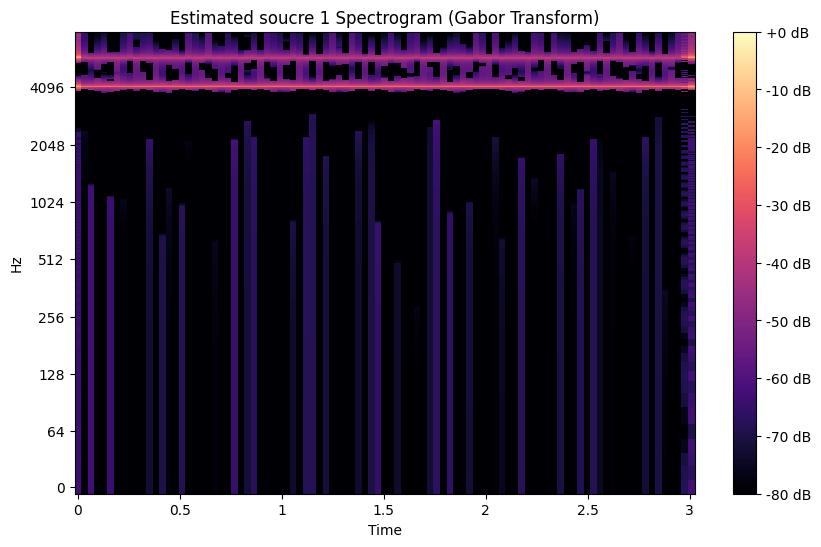

0.5143276717745461


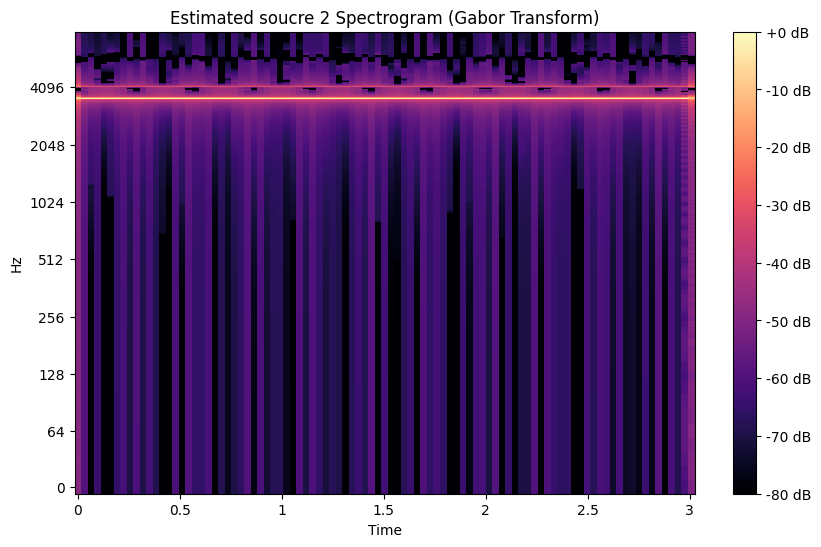

0.10914050376555381


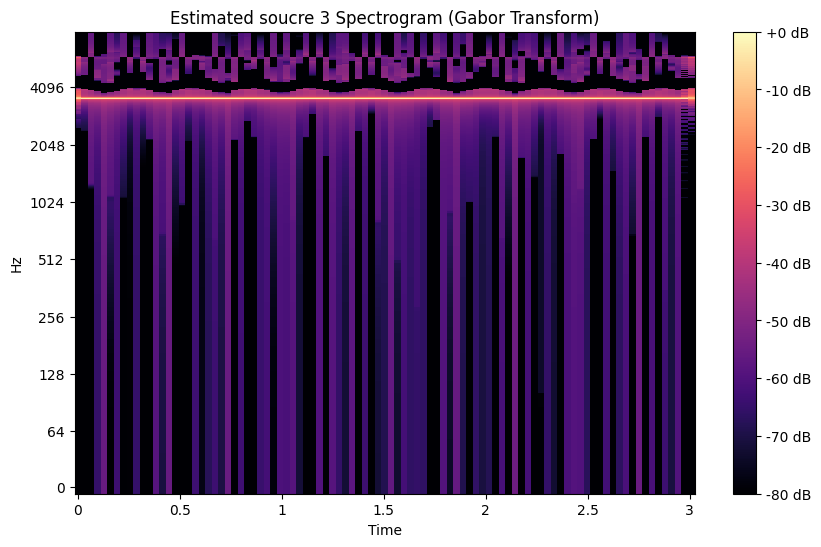

###################################################The method is  proximal #########################################################################


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:123: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


The mean suqare error of delays is  nan
The True matrix is 
 [[0. 0.]
 [0. 0.]
 [0. 0.]]
The estiamted matrix is 
 [[0. 0.]
 [0. 0.]
 [0. 0.]]
The mean suqare error of attenutaion is  0.11529729311555122
The True matrix is 
 [[0.89647335 0.44309765]
 [0.99984315 0.0177111 ]
 [0.93583791 0.35243072]]
The estiamted matrix is 
 [[0.89982816 0.42683167]
 [0.98008472 0.18270532]
 [0.58088757 0.79062339]]


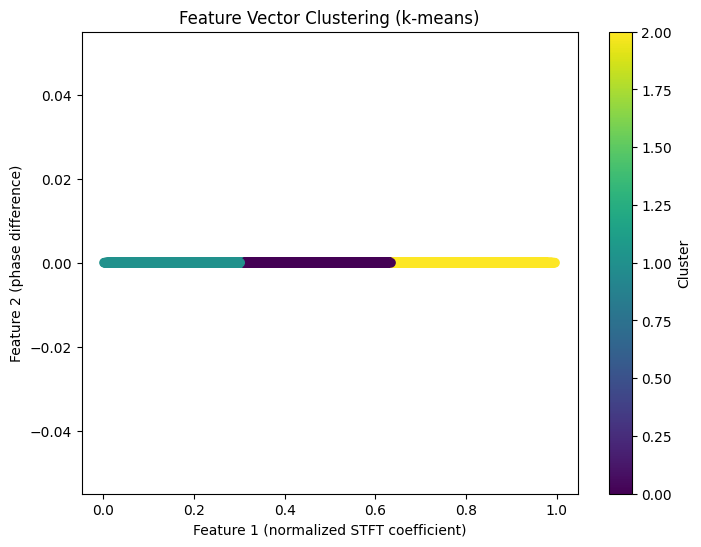

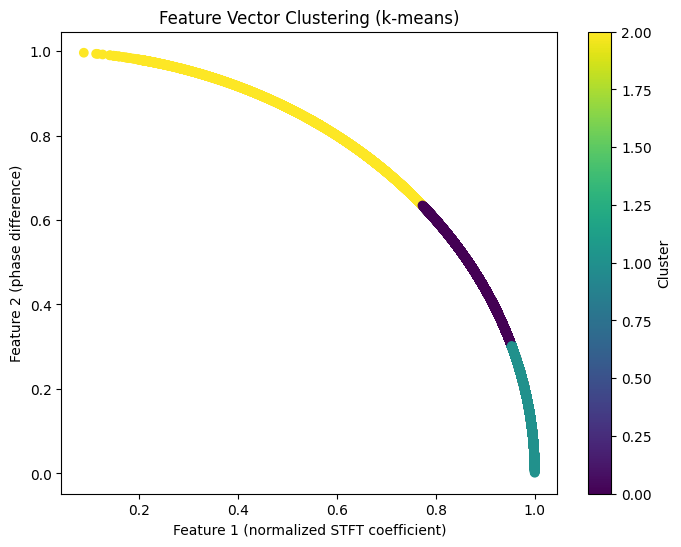

0.9999892913514205


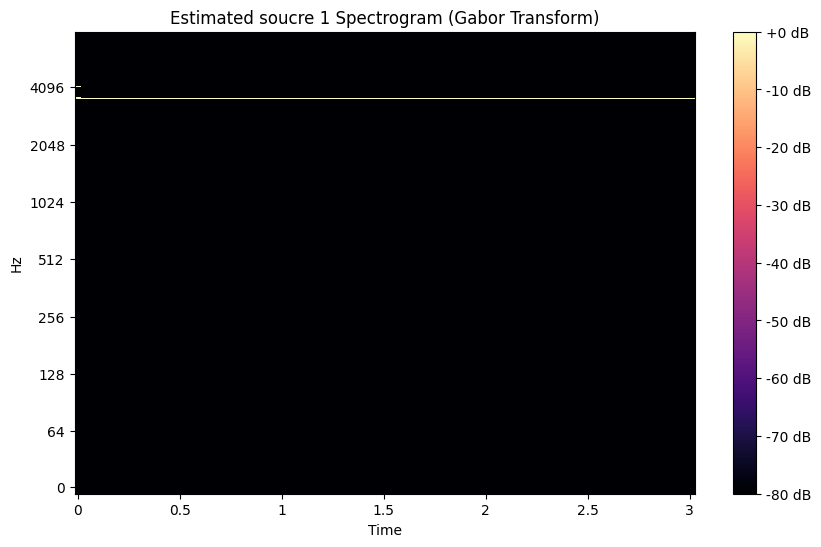

1.0000068475680013


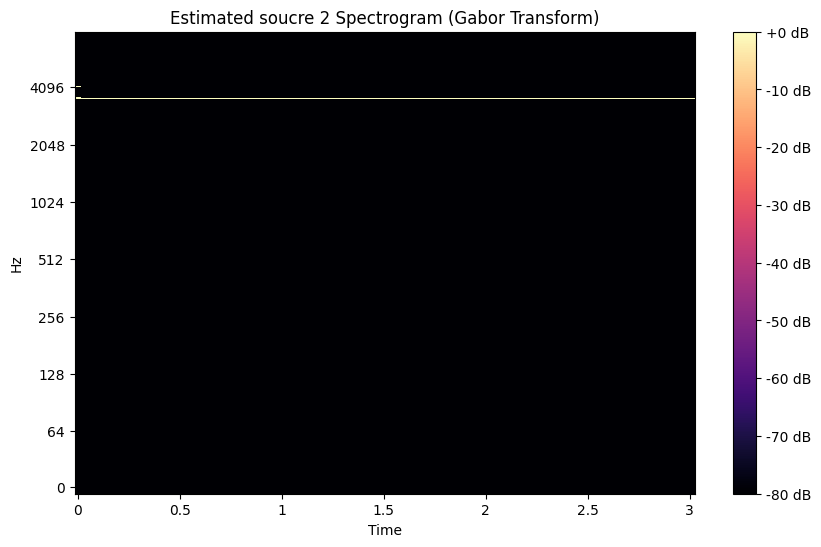

1.000005010824931


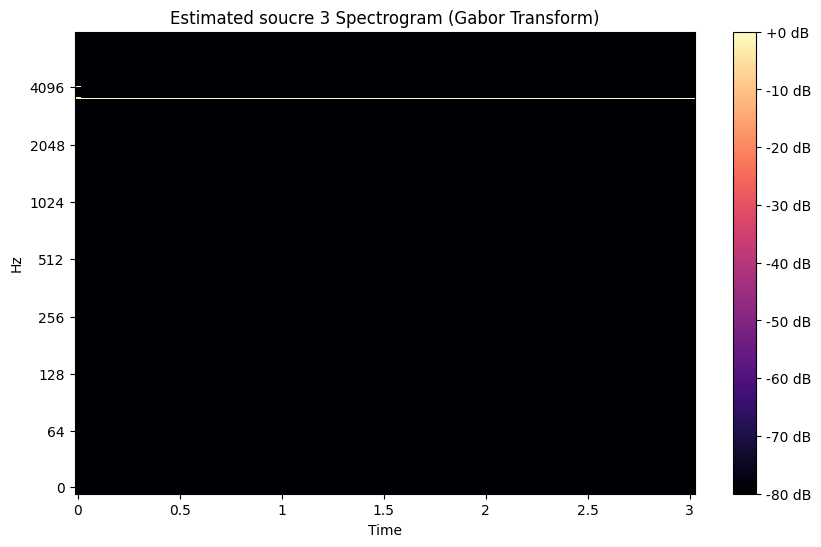

###################################################The method is  CVXPY #########################################################################


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18192\2054076689.py:123: RuntimeWarning: invalid value encountered in scalar divide
  self.mse = np.mean((self.delays_est - Matrix_delays)**2) /  np.mean( Matrix_delays**2)


The mean suqare error of delays is  nan
The True matrix is 
 [[0. 0.]
 [0. 0.]
 [0. 0.]]
The estiamted matrix is 
 [[0. 0.]
 [0. 0.]
 [0. 0.]]
The mean suqare error of attenutaion is  0.18983881183234344
The True matrix is 
 [[0.89647335 0.44309765]
 [0.99984315 0.0177111 ]
 [0.93583791 0.35243072]]
The estiamted matrix is 
 [[0.98010687 0.18260885]
 [0.89992015 0.42665244]
 [0.58127716 0.79030799]]


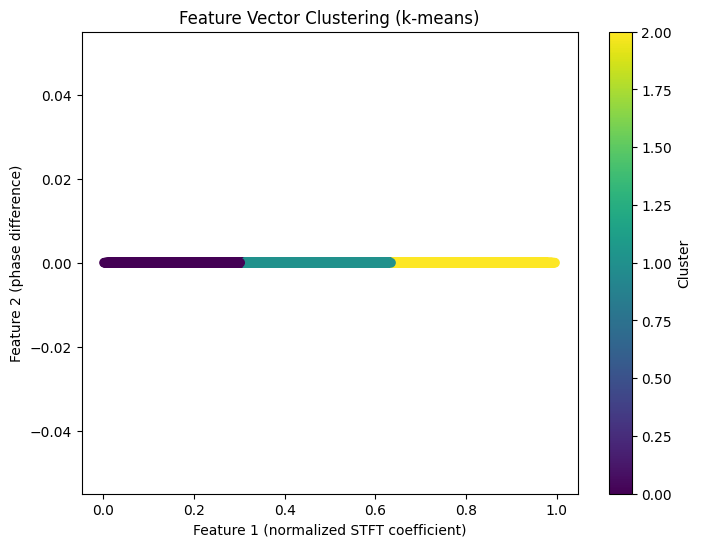

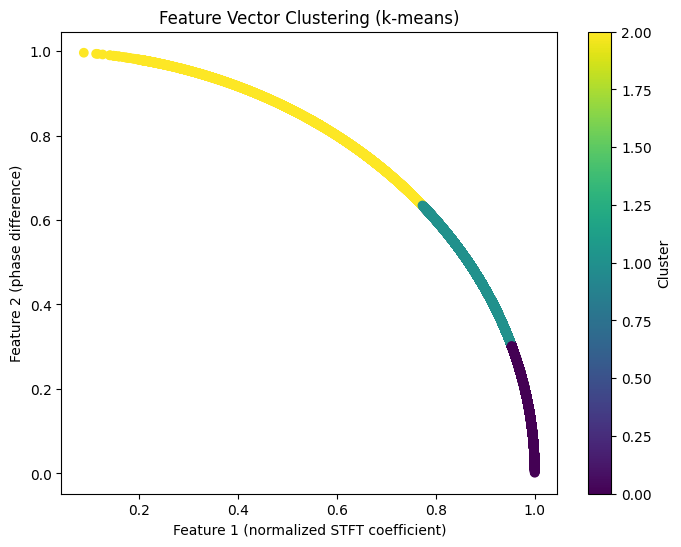

In [ ]:
for mn in method_names: 
    print("###################################################The method is ",mn , "#########################################################################")
    system1= System(mixtures, n_sources, window_size= window_size,hop_length=hop_length,sr= sr)
    system1.compute_gabor_transform_with_f_t()
    system1.compute_feature_vectors()
    system1.compute_k_means()

    system1.estimate_aij_and_deltaij()
    system1.delays_est=system1.delays_est 
    system1.Mean_S_E(mixing_matrix,delays)
    system1.plot_clusters(indx1=1, indx2=2)
    system1.plot_clusters(indx1=0, indx2=1)
    
    system1.simulate_sources_stft(method_name=mn,method_params=method_parameters[mn] )
    rt=system1.get_sources_stft()
    for i, stft in enumerate(rt, 1):
        plot_spectrogram(stft, sr=sr, title=f"Estimated soucre {i} Spectrogram (Gabor Transform)")